In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PHASE 0: Data Loading

In [2]:
df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_dataset.csv')

df.head()

,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed
0,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
1,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
2,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
3,8a9fae838be6a66a018be7e0229327a9,PG for Boys in Perungalathur,12.905105,80.095660,Perungalathur,", Gateway Office Parks Rd near Perungalathur P...",MALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
4,8a9fb38499ce0d630199ce1448fd00e1,PG for Boys in Old Perungalathur,12.918673,80.081292,Shanthi Nagar,Parvathi Nagar near ( GANAPATHY MEN'S HOSTEL ...,MALE,Both,5.9,9.1,...,False,False,False,False,False,False,NaN,False,False,False


1. What is my TARGET variable? 
    - the target variable is `rent`
2. Is this regression or classification?
    - going to use regression, cuz the target is continous
3. What does one ROW represent? 
    - one PG listing (one PG's room)
4. How was this data collected? 
    - the data collected from web scraping
5. What does a MISSING VALUE mean in this domain?

----------------------------------------------------------------------------------
# PHASE 1: SANITY CHECK

- Shape and structure
- Check the datatypes
- Missing Values
- Duplicates
- Unique value count for (categorical)
- Basic stats

In [3]:
# 1.1 shape and structure + dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1783 non-null   str    
 1   title               1783 non-null   str    
 2   latitude            1783 non-null   float64
 3   longitude           1783 non-null   float64
 4   locality            1783 non-null   str    
 5   address             1783 non-null   str    
 6   gender              1783 non-null   str    
 7   available_for       1783 non-null   str    
 8   transit_score       883 non-null    float64
 9   lifestyle_score     883 non-null    float64
 10  occupancy           1759 non-null   str    
 11  rent                1759 non-null   float64
 12  deposit             1759 non-null   float64
 13  attached_bathroom   1759 non-null   object 
 14  food_included       1783 non-null   bool   
 15  breakfast           1783 non-null   bool   
 16  lunch            

## Key observation
    
- our dataset has missing values
- some of the columns have True/False as `object` dtype, so need to change into `bool` data type
    

In [28]:
# 1.2 Missing values
def missing_info(df):
    missing_info = pd.DataFrame({
        'missing count': df.isna().sum(),
        'missing %': (df.isna().mean() * 100).round(2),
        'Data type': df.dtypes,
    })

    missing_info = missing_info[missing_info['missing count'] > 0]
    missing_info.sort_values('missing %', ascending = False)
    return missing_info

In [29]:
missing_info(df)

,missing count,missing %,Data type
transit_score,900,50.48,float64
lifestyle_score,900,50.48,float64
occupancy,24,1.35,str
rent,24,1.35,float64
deposit,24,1.35,float64
attached_bathroom,24,1.35,object
mess,834,46.78,object
wifi,830,46.55,object
laundry,806,45.20,object
power_backup,830,46.55,object


## Key observation from the missing values analysis

### SCORES
- i can see that the scores (transit & lifestylr) are missing around 50%
- so we need to understand why the API did not returned the values?
- ok, as of my obervation about the API, it indicates that the API did not returned these scores for the listing. The exact reason is unknown (e.g., score unavailable or not computed).

### Amenties (wifi, laundry, etc...)

- and these amenities are missing around 45%, we should not drop or impute without validation
- so after validation: 
	by comparing actual JSON response from the API with actual PG (in Website) (eg. analyzed the wifi - True/false/Nan)

- so coclusion the True means = available
        - True means = Pg owner provided the info, as available
        - False means = Pg owner provided the info, as unavailable
        - Nan means = the provider does not provided the actual amenities
        whether the PG has Wifi or not

Assumption:
Listings with an empty amenitiesMap provide no amenity information.
For modeling, missing amenity values are treated as False,
assuming unlisted amenities are unavailable.

### And for some columns has ~1% missing values

- i can see that the target variable also has missing values
- so we can drop these column which have ~1% of missinng values
- it is safe, cuz its just ~1% in our dataset

### and the one coloumn has nearly ~80%+ missing values

- and mainly the `gate_closing_time` lable does'nt seems to be a helpful label
- so i should drop it, without hesitation!

-------------------------------------------------------------------------
## Conlcusion

### scores

Imputation strategy:
- Missingness is preserved using binary indicator columns:
    - transit_score_missing
    - lifestyle_score_missing
- Missing scores are imputed using the median score within the same locality, assuming properties in the same locality have similar accessibility characteristics.
- If an entire locality has missing scores, the remaining NaN values are filled using the global median.

### amenties (wifi, laundry, etc)

- fill False

### droping columns

- columns which have ~1% missing values
- columns which has over ~80% missing values


In [5]:
# 1.3 Duplicates
print(f'Total duplicates: {df.duplicated().sum()}')
df[df.duplicated(keep=False)].sort_values(by = df.columns.tolist()).head(20)

Total duplicates: 162


,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed
830,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
833,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
832,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11:00 PM,True,True,False
835,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11:00 PM,True,True,False
831,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
834,8a9f82038cb9ca57018cbaea42625878,PG for Boys in Tharamani,12.982579,80.238133,Tharamani,"Anna Nagar near Panchamukha Hanuman Temple, Th...",MALE,Both,NaN,NaN,...,False,True,False,False,True,True,11:00 PM,True,True,False
1013,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1016,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1015,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
1018,8a9f84449233260d019233676f89127e,PG for Girls in Tharamani,12.982616,80.238006,Tharamani,"Anna Nagar, near Panchamukha Hanuman Temple, ...",FEMALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False


### Key observation

- exact duplicates rows were found in the dataset
- these duplicates likely originated from overlapped API response or repeated listing (like the pg might listed under tambarm and perungaluthur as well, or new perungalayhur, who knows?)
- since all columns were identical, dups are detected based on `id` `occupancy` these two are the primary key
- These duplicates were removed using drop_duplicates(subset=['id', 'occupancy']), keeping the first occurrence of each unique property-room combination.

------------------------------------------------------------------------
### Conclusion

removes rows which are identical based on these two pairs `id` `occupancy`

```py
df_clean = df.drop_duplicates(subset=['id', 'occupancy'])
```

In [13]:
# 1.4 Unique valu counts (categorical)
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].nunique()} unique -> {df[col].unique()[:10]}')

id: 657 unique -> <StringArray>
['8aa9ba0d9ef7b08b019ef7beaaeb030e', '8a9fae838be6a66a018be7e0229327a9',
 '8a9fb38499ce0d630199ce1448fd00e1', '8aa98e6a9c1c4dca019c1cc70bf621a8',
 '8aa98e979b82e1a4019b83d99c297a01', '8a9f9182844bc06501844c39248d6b15',
 'ff808181547b7f2801547f8dfa492a85', '8a9fa98495832f000195836bfe450c9d',
 '8aa9aa7e9c64d498019c65163c521ee1', '8a9fae85971a0e6d01971a5203a7105b']
Length: 10, dtype: str
title: 181 unique -> <StringArray>
['PG for Boys in Anbu Homoeopathy And Acupuncture Clinic',
                           'PG for Boys in Perungalathur',
                       'PG for Boys in Old Perungalathur',
                         'PG for Boys in Shollinganallur',
                       'PG for Boys in New Perungalathur',
                          'PG for Boys in Perungalathur,',
                          'PG for Boys in West Tambaram ',
                            'PG for Boys in Third Street',
                        'PG for Boys in Otteri Extension',
              

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_5348\2567202304.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### KEy observation

- `id` uniquesly identifies each property, its an identifier column and this wont help in modeling
- `title` it doesnt contain necessary infos, should be droped
- `locality` contains 36 unique categories and is expexted to influence rent, so encode
- `address` not needed 
- `gender` 3 categories, easy to encode
- `available_for` again 3 categories, looks clean
- `occupancy` 4 categories and Nan also exist other than 4 (need to inspect)
```py
df[df["occupancy"].isna()]
```
- `amenites` can encode this
- `parking` could later encode as 
    - no parking
    - bike
    - car
    - both
- `gate_closing_time` it has ~80% missing values so dont bother about this, ill drop it anyway

In [15]:
# 1.5 Basic stats
df.describe(include=['int64', 'float64'])   # numeric columns


,latitude,longitude,transit_score,lifestyle_score,rent,deposit,total_bathrooms
count,1783.000000,1783.000000,883.000000,883.000000,1759.000000,1759.000000,1783.000000
mean,12.959144,80.208051,7.053001,6.934428,7207.355884,5881.930642,15.365676
std,0.048097,0.050124,2.016839,1.316050,4126.793881,9785.376485,35.519123
min,12.840608,80.040125,-10.000000,1.500000,0.000000,0.000000,0.000000
25%,12.913428,80.212143,6.400000,6.200000,6000.000000,3000.000000,0.000000
50%,12.977430,80.228473,7.600000,6.300000,7000.000000,3000.000000,0.000000
75%,12.985703,80.235708,8.200000,8.100000,8500.000000,5900.000000,12.000000
max,13.115971,80.261954,9.100000,9.600000,65000.000000,200000.000000,215.000000


In [14]:
df.describe(include=['object', 'str']) # categorical column

,id,title,locality,address,gender,available_for,occupancy,attached_bathroom,mess,wifi,...,warden,cooking_allowed,parking,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time
count,1783,1783,1783,1783,1783,1783,1759,1759,949,953,...,977,950,1610,1608,1620,1595,1608,1618,1618,307
unique,657,181,36,624,3,3,4,2,2,2,...,2,2,3,2,2,2,2,2,2,24
top,8a9fd32c84898be701848a319d937c89,PG for Boys in Karapakkam,Tharamani,"Tidel park , Tharamani, Tharamani, chennai",MALE,Both,THREE,False,True,True,...,True,False,Bike,False,False,False,False,False,False,10:30 PM
freq,12,131,269,12,890,1577,546,1401,491,821,...,527,488,1406,1149,1072,1305,1199,1104,1085,68


# PHASE 2: TARGET VARIABLE ANALYSIS

  *Understand about the target variable*   

In [11]:
df_target = df['rent']
df_target.describe()

count     1759.000000
mean      7207.355884
std       4126.793881
min          0.000000
25%       6000.000000
50%       7000.000000
75%       8500.000000
max      65000.000000
Name: rent, dtype: float64

# Quick Visualization check for outliers

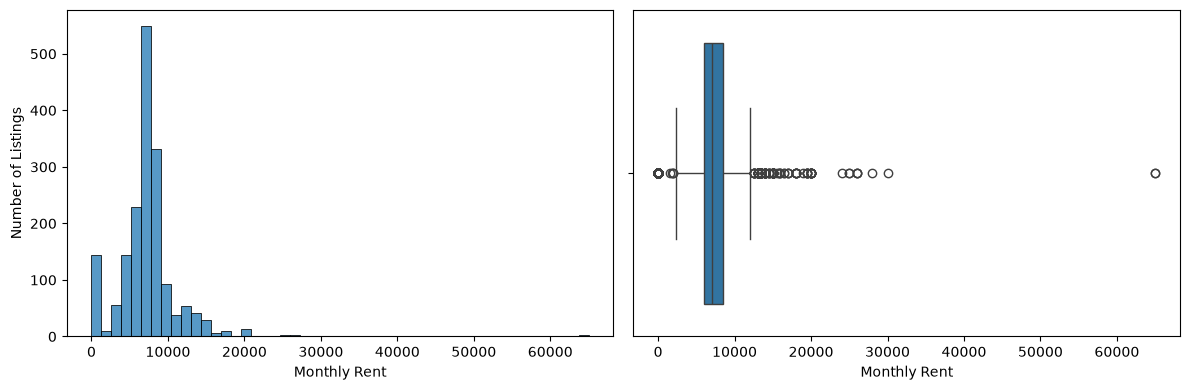

Skewness: 3.7248976386378025


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(
    data=df,
    x='rent',
    bins=50,
    ax = axes[0]
)
axes[0].set_xlabel("Monthly Rent")
axes[0].set_ylabel("Number of Listings")

# Boxplot
sns.boxplot(
    data = df,
    x = 'rent',
    ax = axes[1]
)
axes[1].set_xlabel("Monthly Rent")

plt.tight_layout()
plt.show()


# Skewness
print(f"Skewness: {df_target.skew()}")

### Key Observations:
- Rent distribution is heavily right-skewed (skewness = 3.72).
- Majority of PGs are priced between ₹6,000 and ₹10,000.
- A few listings have unusually high rents (>₹20,000), with one extreme value around ₹65,000.
- Several listings have rent = 0, which requires further investigation. (edit: total 142 rows has 0 values)
- Boxplot confirms the presence of multiple upper-tail outliers.